<a href="https://colab.research.google.com/github/ella941223-cyber/Programming-Language/blob/main/%E3%80%8CHW1_%E6%97%A5%E5%B8%B8%E6%94%AF%E5%87%BA%E9%80%9F%E7%AE%97%E8%88%87%E5%88%86%E6%94%A4_Gradio_ipynb%E3%80%8D_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#日常支出速算與分攤（作業一）
- 目標：從 Sheet 讀「消費紀錄」→ 計總額/分類小計/AA 分攤 → 寫回 Sheet Summary 分頁。
- 額外功能：
  1. 可以撤銷上一筆記帳
  2. 可以清除所有歷史資料
  3. 附上圓餅圖更好查看消費習慣
  4. 彙整部分可選擇月份查看
- Sheet 欄位：date, time, classification, item, amount, payer, place, method, remark

GoogleSheet: https://docs.google.com/spreadsheets/d/1jR3qRQr2ZvWYKNuv8wen_-eTZWdc5a-LLvH7iymn2zw/edit?usp=sharing

In [1]:
# 1. 安裝中文字型
!apt-get install -y fonts-noto-cjk

# 2. 清除 Matplotlib 快取 (這一步很重要，否則它找不到新安裝的字型)
import matplotlib as mpl
import os
import shutil

cache_dir = mpl.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print(f"已清除快取：{cache_dir}")

print("安裝完成！請點選上方選單：『Runtime』 -> 『Restart session』(重啟工作階段)")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
已清除快取：/root/.cache/matplotlib
安裝完成！請點選上方選單：『Runtime』 -> 『Restart session』(重啟工作階段)


In [2]:
import gradio as gr
import pandas as pd
import datetime
import gspread
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import auth
from google.auth import default

In [3]:
# 設定使用 Noto Sans CJK JP (通常安裝完 Noto CJK 後可用這個名稱)
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False  # 用來正常顯示負號

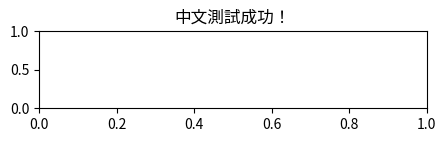

In [4]:
# 測試一下是否成功
plt.figure(figsize=(5,1))
plt.title("中文測試成功！")
plt.show()

In [5]:
SHEET_URL = "https://docs.google.com/spreadsheets/d/1CEUaBeqPvLAKqdYnz0KVSe7QNkBYWbNbfs0-VhwvY8c/edit?usp=sharing"
WORKSHEET_NAME = "工作表1"

REQUIRED_COLUMNS = ["日期", "時間", "分類", "品項", "金額", "付款人", "地點", "支付方式", "備註"]

_auth_done = False
_gc = None
_ws = None

In [7]:
# 【新增函數：取得月份清單】
def _get_month_list(df):
    if df.empty or "日期" not in df.columns:
        return ["全部"]
    # 擷取日期欄位的前 7 碼 (YYYY/MM)
    months = df["日期"].str[:7].unique().tolist()
    # 排除非日期格式的文字並排序
    months = [m for m in months if len(m) == 7 and m[4] == '/']
    return ["全部"] + sorted(months, reverse=True)

def _ensure_auth_and_ws():
    global _auth_done, _gc, _ws
    if not _auth_done:
        auth.authenticate_user()
        creds, _ = default()
        _gc = gspread.authorize(creds)
        _auth_done = True
    if _ws is None:
        gs = _gc.open_by_url(SHEET_URL)
        _ws = gs.worksheet(WORKSHEET_NAME)
        _ensure_headers()
    return _ws

def _ensure_headers():
    rows = _ws.get_all_values()
    if not rows:
        _ws.append_row(REQUIRED_COLUMNS, value_input_option="USER_ENTERED")
        return
    header = rows[0]
    if header != REQUIRED_COLUMNS:
        _ws.update('1:1', [REQUIRED_COLUMNS])

def _read_df():
    ws = _ensure_auth_and_ws()
    values = ws.get_all_values()
    if len(values) <= 1:
        return pd.DataFrame(columns=REQUIRED_COLUMNS)
    df = pd.DataFrame(values[1:], columns=values[0])
    if "金額" in df.columns:
        df["金額"] = pd.to_numeric(df["金額"], errors="coerce").fillna(0.0)
    return df

def _make_pie_chart(by_cat_df):
    if by_cat_df.empty or by_cat_df["金額"].sum() == 0:
        return None
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(by_cat_df["金額"], labels=by_cat_df["分類"], autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
    ax.set_title("支出分類佔比")
    return fig

def _make_summary_tables(df, num_people=1):
    if df.empty:
        return pd.DataFrame(columns=["分類", "金額"]), pd.DataFrame()
    by_cat = df.groupby("分類", as_index=False)["金額"].sum().sort_values("金額", ascending=False)
    df_aa = df[df["備註"].str.contains("AA", na=False)].copy()
    if df_aa.empty:
        return by_cat, pd.DataFrame(columns=["付款人", "實付", f"應付(分攤/{num_people}人)", "差額"])
    total_aa_amount = df_aa["金額"].sum()
    aa_share = total_aa_amount / max(num_people, 1)
    paid_by = df_aa.groupby("付款人", as_index=False)["金額"].sum().rename(columns={"金額": "實付"})
    paid_by[f"應付(分攤/{num_people}人)"] = aa_share
    paid_by["差額(多退少補)"] = paid_by["實付"] - aa_share
    return by_cat, paid_by.sort_values("差額(多退少補)", ascending=False)

def add_expense(date_str, time_str, category, item, amount, payer, place, method, remark, num_people):
    try:
        if not date_str: date_str = datetime.date.today().strftime("%Y/%m/%d")
        category = (category or "未填").strip()
        item = (item or "未填").strip()
        payer = (payer or "匿名").strip()
        place = (place or "未填").strip()
        method = (method or "未設定").strip()
        remark = (remark or "無").strip()
        amount_val = float(amount)
        ws = _ensure_auth_and_ws()
        ws.append_row([date_str, time_str or "", category, item, amount_val, payer, place, method, remark], value_input_option="USER_ENTERED")
        df = _read_df()
        cat, settle = _make_summary_tables(df, num_people)
        pie = _make_pie_chart(cat)
        return "✅ 已新增", float(df["金額"].sum()), cat, settle, pie
    except Exception as e:
        return f"❌ 失敗：{e}", 0, None, None, None

def undo_last_entry(num_people):
    try:
        ws = _ensure_auth_and_ws()
        values = ws.get_all_values()
        if len(values) <= 1: return "⚠️ 無資料可撤銷", 0, None, None, None
        ws.delete_rows(len(values))
        df = _read_df()
        cat, settle = _make_summary_tables(df, num_people)
        pie = _make_pie_chart(cat)
        return "⏪ 已撤銷最後一筆", float(df["金額"].sum()) if not df.empty else 0, cat, settle, pie
    except Exception as e:
        return f"❌ 失敗：{e}", 0, None, None, None

# 【修改函數：加入月份篩選邏輯】
def refresh_summary(num_people, month_filter):
    try:
        df = _read_df()
        if df.empty: return "📭 沒有資料", 0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), None, gr.update(choices=["全部"])

        # 更新月份下拉選單的選項
        new_months = _get_month_list(df)

        # 執行月份過濾
        if month_filter != "全部":
            df = df[df["日期"].str.startswith(month_filter)]

        if df.empty: return f"📅 {month_filter} 沒有資料", 0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), None, gr.update(choices=new_months)

        cat, settle = _make_summary_tables(df, num_people)
        pie = _make_pie_chart(cat)
        return "✅ 已更新", float(df["金額"].sum()), cat, settle, df, pie, gr.update(choices=new_months)
    except Exception as e:
        return f"❌ 錯誤：{e}", 0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), None, gr.update()

def clear_history(confirm):
    if not confirm: return "⚠️ 未勾選確認", 0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), None
    ws = _ensure_auth_and_ws()
    ws.resize(rows=1)
    return "🔥 已清空", 0, pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), None

# --- Gradio UI ---
with gr.Blocks(title="日常支出速算與分攤") as demo:
    gr.Markdown("## 🧾 日常支出速算與分攤")
    num_people_input = gr.Number(label="預設分攤人數", value=1, precision=0)

    with gr.Tab("➕ 新增支出"):
        with gr.Row():
            date_in = gr.Textbox(label="日期", value=datetime.date.today().strftime("%Y/%m/%d"))
            time_in = gr.Textbox(label="時間")
        with gr.Row():
            cat_in = gr.Textbox(label="分類", placeholder="如 外食 / 交通 / 購物")
            item_in = gr.Textbox(label="品項", placeholder="如 咖啡 / 便當 / 車票")
            amt_in = gr.Textbox(label="金額", placeholder="數字")
        with gr.Row():
            payer_in = gr.Textbox(label="付款人", placeholder="如 Pecu / Alice / Bob")
            place_in = gr.Textbox(label="地點")
            method_in = gr.Textbox(label="支付方式", placeholder="如 現金 / 刷卡")
        remark_in = gr.Textbox(label="備註 (含 AA 啟動分帳)", placeholder="備註AA可使用分帳功能")

        with gr.Row():
            add_btn = gr.Button("新增", variant="primary")
            undo_btn = gr.Button("⏪ 撤銷上一筆")

        add_msg = gr.Markdown()
        with gr.Row():
            total_out = gr.Number(label="總額", interactive=False)
            pie_out = gr.Plot(label="消費分佈圖")
        with gr.Row():
            cat_df = gr.Dataframe(label="分類小計")
            settle_df = gr.Dataframe(label="AA 分攤")

        add_btn.click(
            fn=add_expense,
            inputs=[date_in, time_in, cat_in, item_in, amt_in, payer_in, place_in, method_in, remark_in, num_people_input],
            outputs=[add_msg, total_out, cat_df, settle_df, pie_out]
        )
        undo_btn.click(fn=undo_last_entry, inputs=[num_people_input], outputs=[add_msg, total_out, cat_df, settle_df, pie_out])

    with gr.Tab("📊 彙總報表"):
        # 【新增組件：月份選擇下拉選單】
        month_select = gr.Dropdown(label="篩選月份", choices=["全部"], value="全部")

        refresh_btn = gr.Button("整理數據與更新圖表")
        msg2 = gr.Markdown()
        total2 = gr.Number(label="累積金額")
        with gr.Row():
            pie_out2 = gr.Plot(label="支出圓餅圖")
            cat_df2 = gr.Dataframe(label="分類清單")
        settle_df2 = gr.Dataframe(label="結算表")
        raw_preview = gr.Dataframe(label="原始資料")

        # 【修改事件連結：加入 month_select 為輸入，並輸出更新選單】
        refresh_btn.click(
            fn=refresh_summary,
            inputs=[num_people_input, month_select],
            outputs=[msg2, total2, cat_df2, settle_df2, raw_preview, pie_out2, month_select]
        )

        # 【新增事件：切換月份時自動刷新】
        month_select.change(
            fn=refresh_summary,
            inputs=[num_people_input, month_select],
            outputs=[msg2, total2, cat_df2, settle_df2, raw_preview, pie_out2, month_select]
        )

    with gr.Tab("⚙️ 清除所有資料"):
        confirm_check = gr.Checkbox(label="確定清空資料")
        clear_btn = gr.Button("🔥 清除所有", variant="stop")
        clear_btn.click(fn=clear_history, inputs=[confirm_check], outputs=[gr.Markdown(), total2, cat_df2, settle_df2, raw_preview, pie_out2])

demo.launch(share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>